In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("games.csv", sep=',', on_bad_lines='skip', engine='python')
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
df[['Price', 'Positive', 'Negative', 'Metacritic score', 'Average playtime forever']].describe()

,Price,Positive,Negative,Metacritic score,Average playtime forever
count,41099.000000,4.109900e+04,4.109900e+04,41099.000000,4.109900e+04
mean,13.613470,1.098782e+03,1.950677e+02,2.622302,2.474616e+02
std,26.317448,2.110702e+04,6.277534e+03,13.820807,1.705282e+04
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
50%,0.000000,5.000000e+00,1.000000e+00,0.000000,0.000000e+00
75%,0.000000,3.700000e+01,1.100000e+01,0.000000,0.000000e+00
max,100.000000,2.037143e+06,1.037487e+06,95.000000,3.429544e+06


In [4]:
df['positive_rate'] = df['Positive'] / (df['Positive'] + df['Negative'])
df_filtered = df[(df['Price'] > 0) & (df['positive_rate'].notna())].copy()
df['positive_rate'].describe()

count    27968.000000
mean         0.759432
std          0.238830
min          0.000000
25%          0.653414
50%          0.821754
75%          0.944444
max          1.000000
Name: positive_rate, dtype: float64

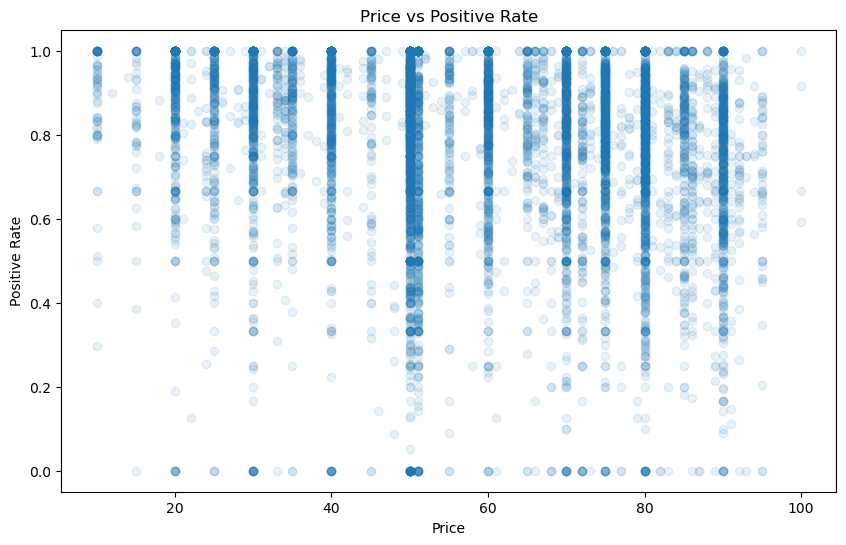

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['Price'], df_filtered['positive_rate'], alpha=0.1)
plt.xlabel('Price')
plt.ylabel('Positive Rate')
plt.title('Price vs Positive Rate')
plt.show()

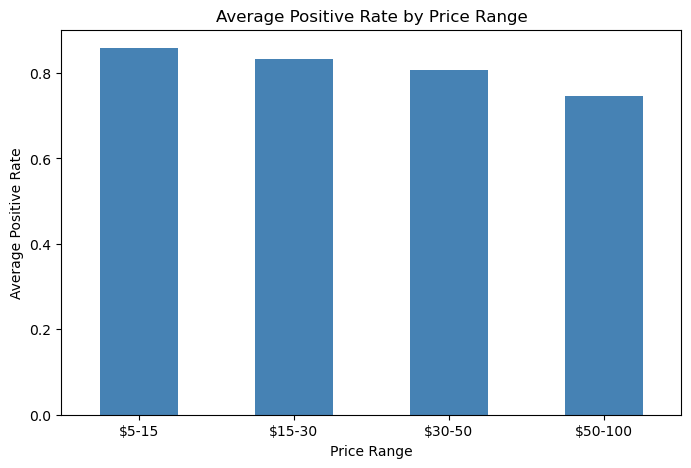

In [6]:
df_filtered['price_range'] = pd.cut(df_filtered['Price'], 
                                     bins=[0, 5, 15, 30, 50, 100], 
                                     labels=['$0-5', '$5-15', '$15-30', '$30-50', '$50-100'])
avg_by_price = df_filtered.groupby('price_range', observed=True)['positive_rate'].mean()

plt.figure(figsize=(8, 5))
avg_by_price.plot(kind='bar', color='steelblue')
plt.xlabel('Price Range')
plt.ylabel('Average Positive Rate')
plt.title('Average Positive Rate by Price Range')
plt.xticks(rotation=0)
plt.show()

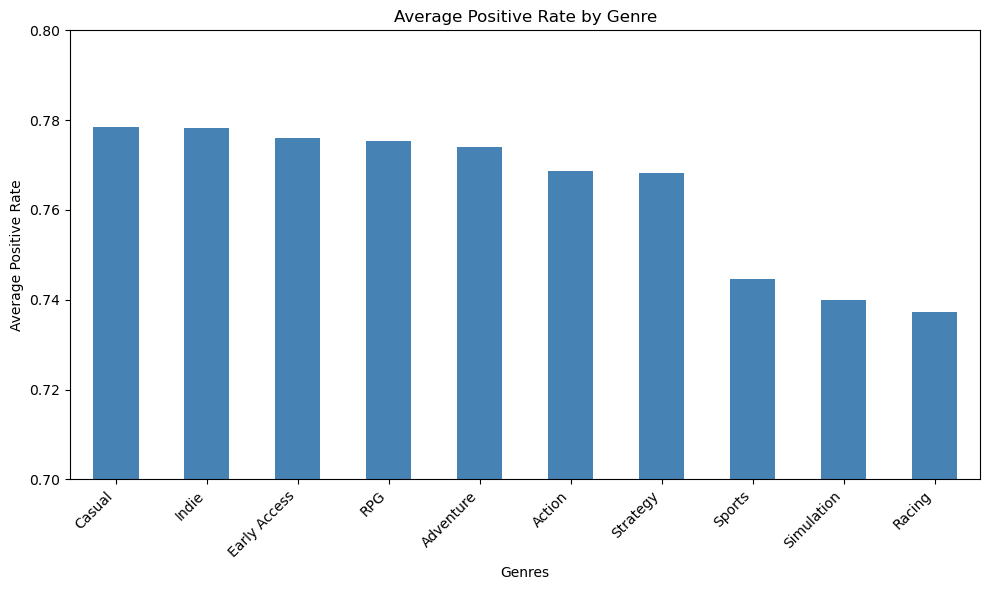

In [7]:
genres_df = df_filtered.dropna(subset=['Genres']).copy()
genres_df['Genres'] = genres_df['Genres'].str.split(',')
genres_exploded = genres_df.explode('Genres')
genres_exploded['Genres'] = genres_exploded['Genres'].str.strip()

genre_rating = genres_exploded.groupby('Genres')['positive_rate'].agg(['mean', 'count'])
genre_rating = genre_rating[genre_rating['count'] > 100].sort_values('mean', ascending=False)

plt.figure(figsize=(10, 6))
genre_rating['mean'].plot(kind='bar', color='steelblue')
plt.xlabel('Genres')
plt.ylabel('Average Positive Rate')
plt.title('Average Positive Rate by Genre')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 0.8)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("games.csv", sep=',', on_bad_lines='skip', engine='python')
df['positive_rate'] = df['Positive'] / (df['Positive'] + df['Negative'])
df_filtered = df[(df['Price'] > 0) & (df['positive_rate'].notna())].copy()

print("ready")

ready


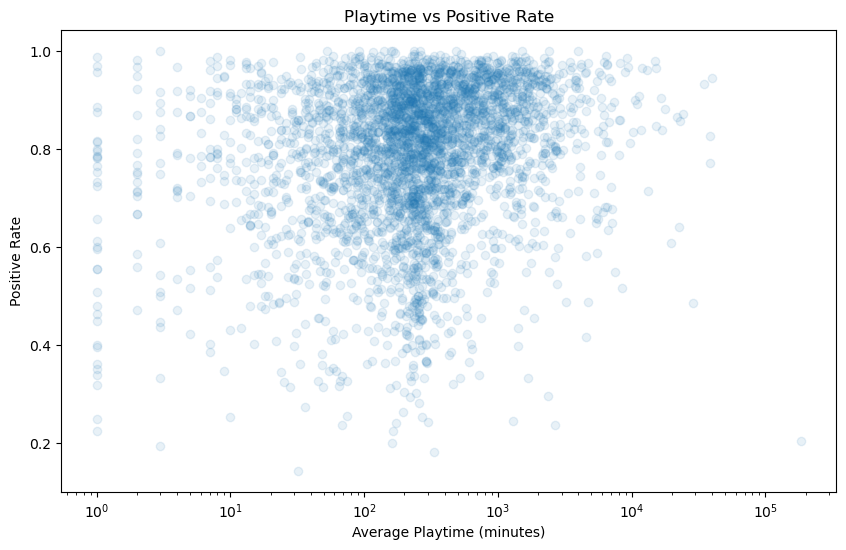

In [2]:
df_playtime = df_filtered[df_filtered['Average playtime forever'] > 0].copy()

plt.figure(figsize=(10, 6))
plt.scatter(df_playtime['Average playtime forever'], 
            df_playtime['positive_rate'], alpha=0.1)
plt.xlabel('Average Playtime (minutes)')
plt.ylabel('Positive Rate')
plt.title('Playtime vs Positive Rate')
plt.xscale('log') 
plt.show()

In [3]:
correlation = df_playtime[['Average playtime forever', 'positive_rate']].corr()
print(correlation)

                          Average playtime forever  positive_rate
Average playtime forever                  1.000000      -0.014487
positive_rate                            -0.014487       1.000000


In [4]:
print(df['DiscountDLC count'].describe())

count    41099.000000
mean         0.488187
std          7.212872
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        875.000000
Name: DiscountDLC count, dtype: float64


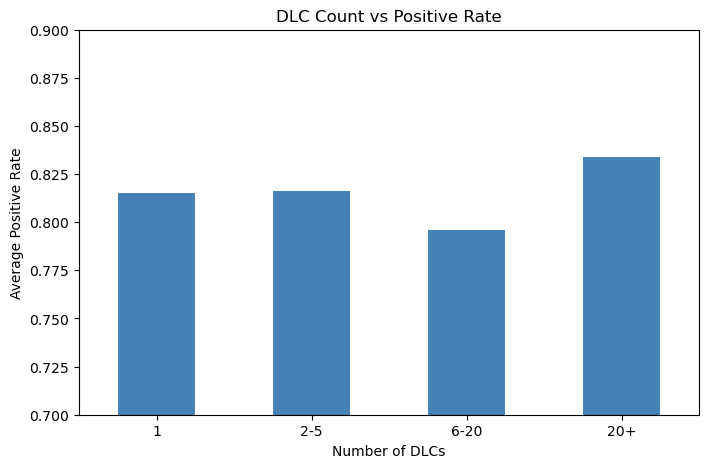

In [5]:
df_dlc = df_filtered[df_filtered['DiscountDLC count'] > 0].copy()
df_dlc['dlc_range'] = pd.cut(df_dlc['DiscountDLC count'],
                              bins=[0, 1, 5, 20, 875],
                              labels=['1', '2-5', '6-20', '20+'])

avg_by_dlc = df_dlc.groupby('dlc_range', observed=True)['positive_rate'].mean()

plt.figure(figsize=(8, 5))
avg_by_dlc.plot(kind='bar', color='steelblue')
plt.xlabel('Number of DLCs')
plt.ylabel('Average Positive Rate')
plt.title('DLC Count vs Positive Rate')
plt.xticks(rotation=0)
plt.ylim(0.7, 0.9)
plt.show()